<a href="https://colab.research.google.com/github/jaydenjung-bohs09/jaydenjung-bohs09.github.io/blob/main/Copy_of_DTI_Fixed_Embeddings_MLP_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color=darkblue> **Drug–Target Affinity Prediction on the PBCNet2.0 dataset** </font>

## <font color=darkblue> A Simple Example with Fixed LM Embeddings + MLP Head </font>

### **Data**

- PBCNet2.0 dataset: `pbcnet2_bindingdb_combined_uniprot_with_splits.tsv`
- About 492k rows, covering 344k unique drugs and 1,836 unique proteins
- We use the train/validation/test split that comes with the original dataset

### **Model Architecture**

This follows the same high-level idea as the DeepPurpose DTI framework, with the encoders swapped for **frozen pretrained language models**:

**ChemBERTa** (drug SMILES) + **ESM-2** (protein sequence) → *fixed* embeddings → **concat → MLP head** → predicted affinity.

The drug and protein are each turned into a vector, those two vectors are joined together, and a small multilayer perceptron reads the combination and predicts the binding affinity.

### **Representations**

The two language models are used only as fixed feature extractors, so we never fine-tune them. We run each model **once** over the unique drugs and proteins, save the resulting embedding vectors to Google Drive, and from then on train only the small MLP head on top of those cached vectors.

Keeping the encoders frozen is what makes this cheap to run. The expensive part (passing everything through the big models) happens a single time, and every later experiment reuses the saved vectors, so the whole notebook stays comfortably within the free Colab GPU and Drive limits.


### **How to run**

You may run the language model inference on either CPU or GPU. To save compute units, make sure you save the embedding vectors as instructed so that you only need to run it once.

For training scaled up predictors, GPU helps to speed the training process. You may change runtime type by:

`Runtime` / A `🔽` dropdown menu in the upper right corner  → `Change runtime type` → `T4 GPU`.

> <font color=red> **Please be mindful of your team's total compute units and arrange to use them strategically.** In the worst case when everyone in your team has hit compute limit on Colab and couldn't make any progress on the project, please contact the TAs and we will help you figure out some solutions. </font>

## <font color=darkblue> 1. Install & imports </font>

We only need to install 🤗 `transformers` and `rdkit`; everything else already comes with Colab. Please switch to a **GPU runtime** first (`Runtime → Change runtime type → T4 GPU`), since the one-time embedding step is much slower on CPU.

In [ ]:
!pip install -q transformers rdkit

import os, time
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from scipy.stats import pearsonr, spearmanr

torch.manual_seed(0); np.random.seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device, '| GPU:', torch.cuda.get_device_name(0) if device=='cuda' else 'none')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 22.3 MB/s eta 0:00:00
device: cuda | GPU: Tesla T4


## <font color=darkblue> 2. Mount Drive & set paths </font>

Keep your TSV in Google Drive (for example `MyDrive/dti/pbcnet2_bindingdb_combined_with_splits.tsv`) so you don't have to re-upload the file at the start of every session.

The embeddings and checkpoints are saved under `CACHE_DIR`, which means they're computed once and then load back almost instantly the next time you run the notebook.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DATA_TSV  = '/content/drive/MyDrive/dti/kranker.tsv'  # edit if needed
CACHE_DIR = '/content/drive/MyDrive/dti/cache'
os.makedirs(CACHE_DIR, exist_ok=True)

# Total rows to keep in the subsample. Rows are drawn from the dataset's original train/valid/test
# splits in 80/10/10 proportion to reach this total. None = use the full dataset.
SUBSAMPLE_ROWS = None

assert os.path.exists(DATA_TSV), f'TSV not found at {DATA_TSV} — upload it to Drive or fix the path.'
print('ok')

Mounted at /content/drive
ok


In [ ]:
import os

# List the files in the DATA_TSV directory
dti_dir = os.path.dirname(DATA_TSV)
if os.path.exists(dti_dir):
    print(f'Files in {dti_dir}:')
    for filename in os.listdir(dti_dir):
        print(f'- {filename}')
else:
    print(f'The directory {dti_dir} does not exist in your Google Drive. Please ensure the path is correct.')

Files in /content/drive/MyDrive/dti:
- deeppurpose_models
- cache
- kranker.tsv


## <font color=darkblue> 3. Load & prepare the data </font>

Dataset Columns: `Ligand SMILES`, `protein amino acid sequence`, `affinity value`, `experiment type`, `UniProt`, `InterPro family accession`, `InterPro family`, `split`.

Preprocessing steps:

- **Uppercase the protein sequences**: some sequences in the data are lowercase, but ESM-2's tokenizer expects uppercase amino-acid codes.

- **Log-transform the affinity to a p-scale** (matching DeepPurpose; higher = stronger binding):

$$\text{pAffinity} = 9 - \log_{10}\!\left(\text{affinity}_{\text{nM}}\right)$$

> Note: `affinity value` mixes **IC50 / Ki / Kd / EC50** assays. We assume the values are in **nM**. Mixing assay types adds label noise.

- **Split**: follows the file's original `train` / `valid` / `test` split. If `SUBSAMPLE_ROWS` is set, rows are drawn from those existing splits in **80/10/10** proportion to reach the target total

- **Cleaning**: some light cleaning, including removing nans, keeping only positive affinity values, and only using the first entry in the family columns.

In [ ]:
# Load and take a look at the dataset

df = pd.read_csv(DATA_TSV, sep='\t')
df.head()

,Ligand SMILES,protein amino acid sequence,affinity value,experiment type,UniProt,InterPro family accession,InterPro family,split
0,CCC(=O)N[C@H](C(=O)N[C@@H](Cc1ccc(O)cc1)[C@H](...,pqitlwkrplvtikiggqlkealldtgaddtvieemslpgrwkpkm...,3.0,Ki,P03367,NaN,NaN,train
1,CCC(C)[C@@H]1NC(=O)[C@@H](NC[C@@H](O)[C@H](Cc2...,pqitlwkrplvtikiggqlkealldtgaddtvieemslpgrwkpkm...,1.8,Ki,P03367,NaN,NaN,train
2,CCC(C)[C@@H]1NC(=O)[C@@H](NC[C@@H](O)[C@H](Cc2...,pqitlwkrplvtikiggqlkealldtgaddtvieemslpgrwkpkm...,4.0,Ki,P03367,NaN,NaN,train
3,CC(=O)Nc1ccc(NC(=O)c2cc(C(=O)Nc3cccc(C(F)(F)F)...,MSQERPTFYRQELNKTIWEVPERYQNLSPVGSGAYGSVCAAFDTKT...,45.0,IC50,Q16539,IPR050117; IPR008352; IPR038784,Mitogen-activated protein (MAP) kinase; Mitoge...,train
4,CC(=O)Nc1ncc(NC(=O)c2cc(C(=O)Nc3cccc(C(F)(F)F)...,MSQERPTFYRQELNKTIWEVPERYQNLSPVGSGAYGSVCAAFDTKT...,1730.0,IC50,Q16539,IPR050117; IPR008352; IPR038784,Mitogen-activated protein (MAP) kinase; Mitoge...,train


In [ ]:
df.columns = ['smiles', 'seq', 'aff', 'assay', 'uniprot', 'family accession', 'family', 'split'] # rename column names for simplicity

df['seq'] = df['seq'].astype(str).str.upper().str.strip()      # ESM-2 needs uppercase
df['aff'] = pd.to_numeric(df['aff'], errors='coerce')          # make sure all the aff labels are numerical values
df = df.dropna(subset=['smiles', 'seq', 'aff'])                # cleaning, drop nan in smiles, seq, aff columns (insufficient training info)
df = df[df['aff'] > 0]                                         # cleaning, only positive affinity value makes sense
df['y'] = 9.0 - np.log10(df['aff'].values)                     # nM -> p-scale

for col in ['family accession', 'family']:                     # cleaning, keep only the first entry in the family columns
    df[col] = df[col].str.split(';', n=1).str[0].str.strip()

df['split'] = df['split'].replace({'val': 'valid'})            # ALWAYS use the file's own split

if SUBSAMPLE_ROWS:                                             # draw 80/10/10 from the existing splits
    target = {'train': 0.8, 'valid': 0.1, 'test': 0.1}
    parts = []
    for sp, fr in target.items():
        g = df[df.split == sp]
        n = min(len(g), int(round(SUBSAMPLE_ROWS * fr)))
        parts.append(g.sample(n, random_state=0))
    df = pd.concat(parts)

train_df = df[df.split == 'train']
valid_df = df[df.split == 'valid']
test_df  = df[df.split == 'test']
print({k: len(v) for k, v in [('train', train_df), ('valid', valid_df), ('test', test_df)]})
print('unique drugs:', df.smiles.nunique(), '| unique proteins:', df.seq.nunique())
print('pAffinity: min %.2f  median %.2f  max %.2f' % (df.y.min(), df.y.median(), df.y.max()))

{'train': 343737, 'valid': 58282, 'test': 26886}
unique drugs: 344337 | unique proteins: 1836
pAffinity: min -0.99  median 7.20  max 14.22


## <font color=darkblue> 4. Visualize the data distribution </font>

A quick look at the data before modeling:
- **label distribution**  (does the transformed pAffinity scores look reasonable? Is it now a more bell-shaped curve?)
- **same distribution split-by-split** (do train/valid/test disribution look alike?)
- **assay-type mix** (how are the experimental affinity labels' assay types mixed together, potentially produces a label-noise source?)
- **protein-length** (how much gets truncated at ESM-2's 1024-token limit)

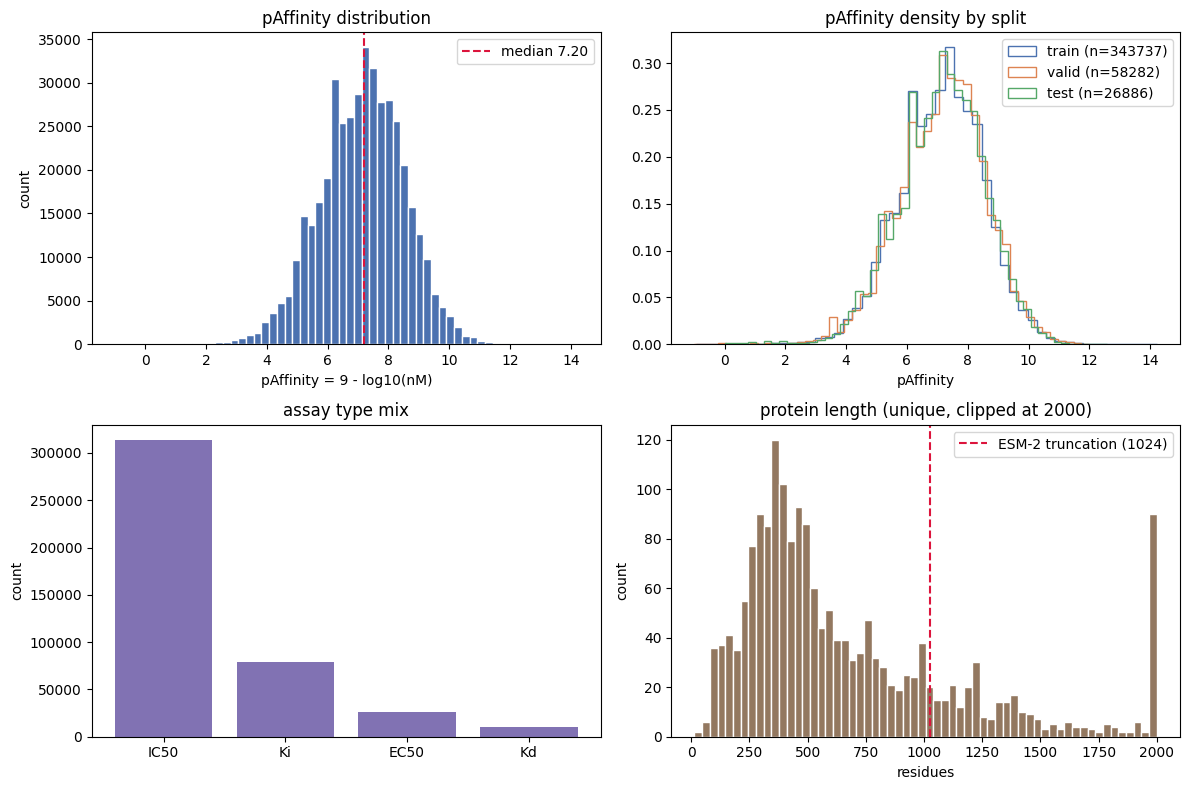

19.1% of unique proteins exceed 1024 residues and get truncated


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# 1) overall pAffinity
ax[0,0].hist(df.y, bins=60, color='#4C72B0', edgecolor='white')
ax[0,0].axvline(df.y.median(), color='crimson', ls='--', label=f'median {df.y.median():.2f}')
ax[0,0].set(title='pAffinity distribution', xlabel='pAffinity = 9 - log10(nM)', ylabel='count'); ax[0,0].legend()

# 2) pAffinity density by split
for sp, c in [('train','#4C72B0'), ('valid','#DD8452'), ('test','#55A868')]:
    d = df[df.split == sp].y
    if len(d):
        ax[0,1].hist(d, bins=50, density=True, histtype='step', lw=2, color=c, label=f'{sp} (n={len(d)})')
ax[0,1].set(title='pAffinity density by split', xlabel='pAffinity'); ax[0,1].legend()

# 3) assay type mix
vc = df.assay.value_counts()
ax[1,0].bar(vc.index, vc.values, color='#8172B3')
ax[1,0].set(title='assay type mix', ylabel='count')

# 4) protein length (unique proteins), clipped for readability
plens = df.drop_duplicates('seq').seq.str.len()
ax[1,1].hist(plens.clip(upper=2000), bins=60, color='#937860', edgecolor='white')
ax[1,1].axvline(1024, color='crimson', ls='--', label='ESM-2 truncation (1024)')
ax[1,1].set(title='protein length (unique, clipped at 2000)', xlabel='residues', ylabel='count'); ax[1,1].legend()

plt.tight_layout(); plt.show()

frac_trunc = (plens > 1024).mean()
print(f'{frac_trunc:.1%} of unique proteins exceed 1024 residues and get truncated')

### Exploring the family column

Now that we've cleaned the `family` column so each row holds a single family (keeping just the first entry before the semicolon), looking at the distribution is pretty straightforward. We can call `value_counts()` directly on the column, which counts how many times each family appears and also drops `NaN`s for us by default. The first cell prints the top 20 so we can see which families dominate the dataset.

Protein family distributions tend to be heavily long-tailed, meaning a handful of families account for most of the rows and there's a long list of rare ones. Plotting all of them at once usually isn't very informative, so in the second cell we just visualize the top 20 as a horizontal bar chart. Horizontal bars are easier to read than vertical ones when the category names are long. Feel free to change `top_n` if you want to see more or fewer.

In [ ]:
counts = df['family'].value_counts()
print(f"Unique families: {len(counts)}")
print(counts.head(20))

Unique families: 603
family
Receptor Tyrosine Kinase                                    26506
G protein-coupled receptor, rhodopsin-like                  20730
Janus Kinase (JAK)                                          19260
Nuclear hormone receptor                                    18803
Non-receptor tyrosine kinases involved in cell signaling    14932
Aspartic peptidase A1                                       12238
Peptidase S1A, chymotrypsin family                          10992
3'5'-cyclic nucleotide phosphodiesterase                     9902
Mitogen-activated protein (MAP) kinase                       9721
Carbonic anhydrase, alpha-class                              8743
Bromodomain-containing chromatin reader                      7533
Cyclin-dependent kinase                                      7085
Phosphatidylinositol 3-/4-kinase                             6623
Peptidase M10A                                               6567
Interleukin-1 receptor-associated kinase 4      

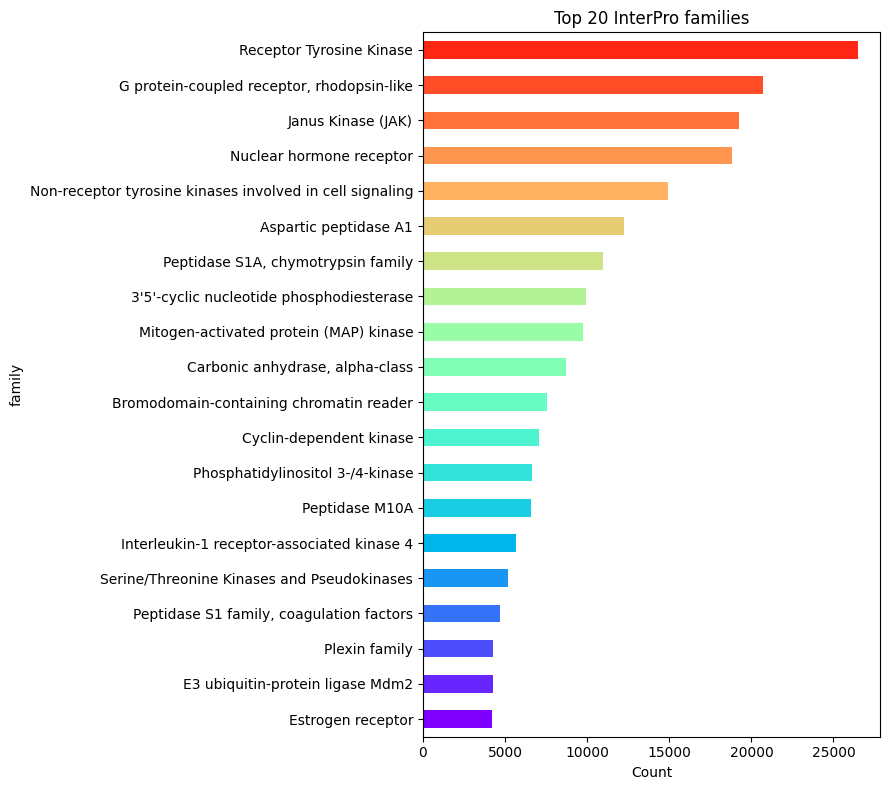

In [ ]:
top_n = 20
top_counts = counts.head(top_n).iloc[::-1]  # reverse so largest is on top

colors = plt.cm.rainbow([i / len(top_counts) for i in range(len(top_counts))])

top_counts.plot(kind='barh', figsize=(9, 8), color=colors)
plt.xlabel('Count')
plt.title(f'Top {top_n} InterPro families')
plt.tight_layout()
plt.show()

## <font color=darkblue> 5. Load the two frozen encoders </font>

Here we demonstrate the smallest useful version of each model so things run quickly. To scale up, you may swap the model names for bigger versions (see the notes at the end).

Both models are frozen, meaning we use them only to produce embeddings and never update their weights.

In [ ]:
from transformers import AutoTokenizer, AutoModel

def load_frozen(name):
    tok = AutoTokenizer.from_pretrained(name)
    model = AutoModel.from_pretrained(name).to(device).eval()
    for p in model.parameters():
        p.requires_grad = False
    return tok, model

esm_tok,  esm_model  = load_frozen('facebook/esm2_t6_8M_UR50D')      # protein
chem_tok, chem_model = load_frozen('DeepChem/ChemBERTa-77M-MLM')     # drug

PROT_DIM = esm_model.config.hidden_size
DRUG_DIM = chem_model.config.hidden_size
print(f'protein dim = {PROT_DIM}, drug dim = {DRUG_DIM}')

config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/420 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MLM
Key                       | Status     | 
--------------------------+------------+-
lm_head.decoder.bias      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


protein dim = 320, drug dim = 384


## <font color=darkblue> 6. Embed every unique drug & protein **once**, cache to Drive (float16) </font>

For each drug and protein we average the model's per-token outputs (masked mean-pooling) to get a single fixed vector. We only do this for the **unique** drugs and proteins, not every row. This matters a lot here, as we have 344k unique drugs in the data but just 1,836 unique proteins, and each protein is reused across roughly 270 rows.

We store the vectors as `float16`, which halves the file size with no meaningful loss in accuracy, and save them to Drive.

If you run this cell again later, it loads the cached vectors in seconds instead of recomputing them.

In [ ]:
@torch.no_grad()
def embed(texts, tokenizer, model, max_length, batch_size):
    out = []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(texts[i:i+batch_size], padding=True, truncation=True,
                        max_length=max_length, return_tensors='pt').to(device)
        h = model(**enc).last_hidden_state
        m = enc['attention_mask'].unsqueeze(-1).float()
        out.append(((h * m).sum(1) / m.sum(1).clamp(min=1e-9)).cpu())
    return torch.cat(out).numpy().astype('float16')

def get_cached(unique, tokenizer, model, max_length, batch_size, tag):
    emb_p  = os.path.join(CACHE_DIR, f'{tag}_emb.npy')
    keys_p = os.path.join(CACHE_DIR, f'{tag}_keys.txt')
    if os.path.exists(emb_p) and os.path.exists(keys_p):
        keys = open(keys_p).read().splitlines()
        emb  = np.load(emb_p)
        if len(keys) == len(unique) and set(keys) == set(unique):
            print(f'[{tag}] loaded cache {emb.shape}')
            return {k: i for i, k in enumerate(keys)}, emb
        print(f'[{tag}] cache stale, recomputing...')
    t = time.time()
    emb = embed(unique, tokenizer, model, max_length, batch_size)
    np.save(emb_p, emb)
    with open(keys_p, 'w') as f:
        f.write('\n'.join(unique))
    print(f'[{tag}] embedded {len(unique)} in {time.time()-t:.0f}s -> {emb.shape}, cached to Drive')
    return {k: i for i, k in enumerate(unique)}, emb

drugs = sorted(df.smiles.unique())
prots = sorted(df.seq.unique())
drug_idx, drug_emb = get_cached(drugs, chem_tok, chem_model, 256, 64, 'chemberta')
prot_idx, prot_emb = get_cached(prots, esm_tok,  esm_model, 1024, 4, 'esm2')

[chemberta] embedded 344337 in 128s -> (344337, 384), cached to Drive
[esm2] embedded 1836 in 27s -> (1836, 320), cached to Drive


## <font color=darkblue> 7. Build index tensors </font>

Instead of materializing a huge `(N_pairs × dim)` matrix, we keep the two compact embedding matrices on the GPU and store, per row, just the **integer indices** into them. Batches gather their vectors on the fly, so that it's cheap in memory and fast on GPU.

In [ ]:
drug_mat = torch.tensor(drug_emb, dtype=torch.float32, device=device)   # (n_drug, DRUG_DIM)
prot_mat = torch.tensor(prot_emb, dtype=torch.float32, device=device)   # (n_prot, PROT_DIM)

def to_tensors(d):
    di = torch.tensor([drug_idx[s] for s in d.smiles], device=device)
    pi = torch.tensor([prot_idx[s] for s in d.seq],   device=device)
    y  = torch.tensor(d.y.values, dtype=torch.float32, device=device).unsqueeze(1)
    return di, pi, y

tr_di, tr_pi, tr_y = to_tensors(train_df)
va_di, va_pi, va_y = to_tensors(valid_df)
te_di, te_pi, te_y = to_tensors(test_df)
print('train/valid/test pairs:', len(tr_y), len(va_y), len(te_y))

train/valid/test pairs: 343737 58282 26886


## <font color=darkblue> 8. The MLP head (identical to DeepPurpose's decoder) </font>

This is the same head that DeepPurpose uses in its `Classifier`. We concatenate the drug and protein embeddings, pass them through a multilayer perceptron with hidden sizes `[1024, 1024, 512]`, apply ReLU with dropout of 0.1 between layers, and finish with a single linear layer that outputs one score. The only thing that changes from the original is the input size, because our embeddings now come from ESM-2 and ChemBERTa.

In [ ]:
class DTIDecoder(nn.Module):
    def __init__(self, drug_dim, prot_dim, hidden=(1024, 1024, 512), dropout=0.1):
        super().__init__()
        dims = [drug_dim + prot_dim] + list(hidden)
        self.layers = nn.ModuleList([nn.Linear(dims[i], dims[i+1]) for i in range(len(hidden))])
        self.out = nn.Linear(hidden[-1], 1)
        self.dropout = nn.Dropout(dropout)
    def forward(self, d, p):
        x = torch.cat([d, p], dim=1)
        for layer in self.layers:
            x = self.dropout(F.relu(layer(x)))
        return self.out(x)

decoder = DTIDecoder(DRUG_DIM, PROT_DIM).to(device)
print(sum(p.numel() for p in decoder.parameters()), 'trainable params')

2296833 trainable params


## <font color=darkblue> 9. Train the head (encoders stay frozen), checkpoint best to Drive </font>

The training process under this pipeline is quick with T4 GPU. Each epoch only updates the small MLP head using the embedding vectors we already cached, so the big ESM-2 and ChemBERTa models never run again here. After every epoch we measure the validation RMSE, keep a copy of the best head so far on Drive, and stop early once it stops improving.

You can adjust the below settings for your own experiments.

**`EXP_NAME`** gives this run a label, which becomes the checkpoint filename (`mlp_head__<EXP_NAME>.pt`). If you leave it as `None`, the notebook builds a name automatically from your settings, such as the encoder versions and how much data you used (for example `ChemBERTa-77M-MLM__esm2_t6_8M_UR50D__full__tr393k`). That way two different experiments won't overwrite each other's checkpoints. If you'd rather name it yourself, just set a string like `"my_run_v1"`.

**`RESUME_FROM_CKPT`** decides where the MLP head starts from. With the default `False`, the head is rebuilt with fresh random weights every time you run the cell, so you always train from scratch. Set it to `True` if you instead want to pick up from an existing checkpoint of the same name and keep training.

**`BATCH`** is how many examples the head looks at per gradient update. Because the embeddings are already computed, larger batches are cheap and make each epoch a little faster and steadier. `512` is a reasonable starting point.

**`EPOCHS`** is the maximum number of full passes over the training set. In practice training usually stops before reaching this because of early stopping.

**`PATIENCE`** controls that early stopping. If the validation RMSE goes this many epochs in a row without improving, training halts and we keep the best checkpoint. Increase it if you want to give the model more chances to improve, or decrease it to stop sooner.

At the end, the head with the lowest validation RMSE is reloaded from Drive before we score the test set, so the test numbers always come from the best version of the model rather than whatever the last epoch happened to produce.

In [ ]:
# ===== experiment identity: unique checkpoint name per setting =====
EXP_NAME = None            # set a string to name it yourself; None = auto-generate
RESUME_FROM_CKPT = False   # True = warm-start from the checkpoint if it exists (not from scratch)

def auto_exp_name():
    chem = chem_model.name_or_path.split('/')[-1]
    esm  = esm_model.name_or_path.split('/')[-1]
    size_tag = f'sub{SUBSAMPLE_ROWS}' if SUBSAMPLE_ROWS else 'full'
    return f'{chem}__{esm}__{size_tag}__tr{len(tr_y)//1000}k'

exp  = (EXP_NAME or auto_exp_name()).replace(' ', '_')
CKPT = os.path.join(CACHE_DIR, f'mlp_head__{exp}.pt')
print('experiment :', exp)
print('checkpoint :', CKPT)

# ===== fresh decoder every run (train from scratch) =====
decoder = DTIDecoder(DRUG_DIM, PROT_DIM).to(device)
if RESUME_FROM_CKPT and os.path.exists(CKPT):
    decoder.load_state_dict(torch.load(CKPT)); print('resumed from checkpoint')

opt = torch.optim.Adam(decoder.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
BATCH, EPOCHS, PATIENCE = 512, 100, 50

def evaluate(di, pi, y):
    decoder.eval()
    with torch.no_grad():
        preds = []
        for i in range(0, len(y), 4096):
            preds.append(decoder(drug_mat[di[i:i+4096]], prot_mat[pi[i:i+4096]]))
        pred = torch.cat(preds).cpu().numpy().ravel()
    yt = y.cpu().numpy().ravel()
    rmse = float(np.sqrt(np.mean((pred - yt) ** 2)))
    return rmse, pearsonr(pred, yt)[0], spearmanr(pred, yt)[0]

best_rmse, wait = float('inf'), 0
for epoch in range(EPOCHS):
    decoder.train()
    perm = torch.randperm(len(tr_y), device=device)
    for i in range(0, len(perm), BATCH):
        idx = perm[i:i+BATCH]
        opt.zero_grad()
        loss = loss_fn(decoder(drug_mat[tr_di[idx]], prot_mat[tr_pi[idx]]), tr_y[idx])
        loss.backward(); opt.step()
    vr, vp, vs = evaluate(va_di, va_pi, va_y)
    if vr < best_rmse:
        best_rmse, wait = vr, 0
        torch.save(decoder.state_dict(), CKPT)
    else:
        wait += 1
    if epoch % 5 == 0 or wait == 0:
        print(f'epoch {epoch:3d} | valid RMSE {vr:.3f}  Pearson {vp:.3f}  Spearman {vs:.3f}'
              + ('  <- best (saved)' if wait == 0 else ''))
    if wait >= PATIENCE:
        print(f'early stop at epoch {epoch}'); break

decoder.load_state_dict(torch.load(CKPT))   # best-of-this-run for the final test eval
tr, tp, ts = evaluate(te_di, te_pi, te_y)
print(f'TEST | RMSE {tr:.3f}  Pearson {tp:.3f}  Spearman {ts:.3f}  [{exp}]')

NameError: name 'chem_model' is not defined

## <font color=darkblue> 10. Predict on a new drug–protein pair </font>

To score a new pair, we embed the SMILES and the sequence with the same frozen encoders and run them through the trained head. The output is the predicted **pAffinity**, where a higher value means stronger predicted binding.

In [ ]:
@torch.no_grad()
def predict(smiles, sequence):
    d = torch.tensor(embed([smiles], chem_tok, chem_model, 256, 1).astype('float32'), device=device)
    p = torch.tensor(embed([sequence.upper()], esm_tok, esm_model, 1024, 1).astype('float32'), device=device)
    decoder.eval()
    return decoder(d, p).item()

demo = test_df.iloc[0]
print('predicted pAffinity =', round(predict(demo.smiles, demo.seq), 2),
      '| true =', round(float(demo.y), 2))

predicted pAffinity = 6.17 | true = 5.75


Testing & Comparing the final and classical model

In [ ]:
import os, time
import numpy as np, pandas as pd
from collections import Counter
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error

np.random.seed(0)
print('good to go')


libraries ready


In [ ]:
df = pd.read_csv(DATA_TSV, sep='\t')
df.columns = ['smiles', 'seq', 'aff', 'assay', 'uniprot',
              'family accession', 'family', 'split']

df['seq'] = df['seq'].astype(str).str.upper().str.strip()
df['aff'] = pd.to_numeric(df['aff'], errors='coerce')
df = df.dropna(subset=['smiles', 'seq', 'aff'])
df = df[df['aff'] > 0]
df['y'] = 9.0 - np.log10(df['aff'].values)        # nM -> p-scale
df['split'] = df['split'].replace({'val': 'valid'})

if SUBSAMPLE_ROWS:
    target = {'train': 0.8, 'valid': 0.1, 'test': 0.1}
    parts = []
    for sp, fr in target.items():
        g = df[df.split == sp]
        n = min(len(g), int(round(SUBSAMPLE_ROWS * fr)))
        parts.append(g.sample(n, random_state=0))
    df = pd.concat(parts)

train_df = df[df.split == 'train']
valid_df = df[df.split == 'valid']
test_df  = df[df.split == 'test']
print({k: len(v) for k, v in [('train', train_df), ('valid', valid_df), ('test', test_df)]})
print('unique drugs:', df.smiles.nunique(), '| unique proteins:', df.seq.nunique())

{'train': 343737, 'valid': 58282, 'test': 26886}
unique drugs: 344337 | unique proteins: 1836


In [ ]:
SMILES_MODE = 'count'   # 'count' or 'presence'
MODEL       = 'rf'      # 'rf' or 'hgb'
print(f'SMILES_MODE = {SMILES_MODE} | MODEL = {MODEL}')

SMILES_MODE = count | MODEL = rf


In [ ]:
# ---- SMILES character vocabulary ----
smiles_vocab = sorted({c for s in df.smiles.unique() for c in s})
sidx = {c: i for i, c in enumerate(smiles_vocab)}
print('SMILES vocab size:', len(smiles_vocab))

def smiles_vec(s):
    v = np.zeros(len(smiles_vocab), dtype=np.float32)
    if SMILES_MODE == 'presence':
        for c in set(s):
            v[sidx[c]] = 1.0
    else:  # 'count'
        for c, n in Counter(s).items():
            v[sidx[c]] = n
    return v

# ---- amino-acid composition ----
AA = 'ACDEFGHIKLMNPQRSTVWYO'
aidx = {a: i for i, a in enumerate(AA)}

def prot_vec(seq):
    v = np.zeros(len(AA), dtype=np.float32)
    if len(seq) == 0:
        return v
    for a, n in Counter(seq).items():
        if a in aidx:
            v[aidx[a]] = n
    return v / len(seq)   # composition (fractions)

# ---- precompute per-unique, then assemble each split ----
t = time.time()
drug_feat = {s: smiles_vec(s) for s in df.smiles.unique()}
prot_feat = {q: prot_vec(q) for q in df.seq.unique()}
print(f'featurized {len(drug_feat)} drugs + {len(prot_feat)} proteins in {time.time()-t:.0f}s')

def build(dframe):
    Xd = np.stack([drug_feat[s] for s in dframe.smiles.values])
    Xp = np.stack([prot_feat[q] for q in dframe.seq.values])
    return np.hstack([Xd, Xp]), dframe.y.values

X_train, y_train = build(train_df)
X_valid, y_valid = build(valid_df)
X_test,  y_test  = build(test_df)
print('feature dim:', X_train.shape[1],
      '| train/valid/test:', X_train.shape[0], X_valid.shape[0], X_test.shape[0])

SMILES vocab size: 42
featurized 344337 drugs + 1836 proteins in 3s
feature dim: 63 | train/valid/test: 343737 58282 26886


In [ ]:
t = time.time()
if MODEL == 'hgb':
    model = HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.06, max_depth=None,
        max_leaf_nodes=63, l2_regularization=1.0,
        early_stopping=True, validation_fraction=0.1, random_state=0)
else:  # 'rf'
    model = RandomForestRegressor(
        n_estimators=200, max_depth=20, min_samples_leaf=3,
        n_jobs=-1, random_state=0)

model.fit(X_train, y_train)
print(f'trained {MODEL} in {time.time()-t:.0f}s')

trained rf in 839s


In [ ]:
def evaluate(name, X, y):
    pred = model.predict(X)
    rmse = float(np.sqrt(mean_squared_error(y, pred)))
    pe   = float(pearsonr(y, pred)[0])
    sp   = float(spearmanr(y, pred)[0])
    print(f'{name:5s} | RMSE {rmse:.3f}  Pearson {pe:.3f}  Spearman {sp:.3f}')
    return rmse, pe, sp

print(f'Classical baseline  ({SMILES_MODE} SMILES + AAC + {MODEL.upper()})')
print('-' * 55)
evaluate('VALID', X_valid, y_valid)
te = evaluate('TEST',  X_test,  y_test)

print('\nTEST | RMSE {:.3f}  Pearson {:.3f}  Spearman {:.3f}'.format(*te))

Classical baseline  (count SMILES + AAC + RF)
-------------------------------------------------------


IndexError: list index out of range